In [5]:
import pandas as pd
import numpy as np
import matplotlib . pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.shape

(7043, 21)

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values after fixing TotalCharges:")
print(df.isnull().sum())


Missing values after fixing TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [18]:

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(" Missing values handled!")
print("Missing values now:", df.isnull().sum().sum())

 Missing values handled!
Missing values now: 0


In [19]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(" Churn column converted!")
print(df['Churn'].value_counts())

 Churn column converted!
Churn
0    5174
1    1869
Name: count, dtype: int64


In [20]:

df['Avg_Monthly_Spend'] = df['TotalCharges'] / (df['tenure'] + 1)


service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['Service_Count'] = (df[service_cols] != 'No').sum(axis=1)


df['Is_LongTerm'] = (df['tenure'] >= 24).astype(int)


df['Is_Monthly_Contract'] = (df['Contract'] == 'Month-to-month').astype(int)


df['Is_AutoPay'] = df['PaymentMethod'].str.contains('automatic', case=False).astype(int)

print(" New features created!")
print(df[['Avg_Monthly_Spend', 'Service_Count', 'Is_LongTerm', 
          'Is_Monthly_Contract', 'Is_AutoPay']].head())

 New features created!
   Avg_Monthly_Spend  Service_Count  Is_LongTerm  Is_Monthly_Contract  \
0          14.925000              3            0                    1   
1          53.985714              4            1                    0   
2          36.050000              4            0                    1   
3          40.016304              5            1                    0   
4          50.550000              2            0                    1   

   Is_AutoPay  
0           0  
1           0  
2           0  
3           1  
4           0  


In [21]:
# Segment customers into High / Medium / Low value
# Based on MonthlyCharges spending

df['Customer_Segment'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 120],
    labels=['Low Value', 'Medium Value', 'High Value']
)

print(" Customer segments created!")
print(df['Customer_Segment'].value_counts())

 Customer segments created!
Customer_Segment
High Value      3899
Low Value       1735
Medium Value    1409
Name: count, dtype: int64


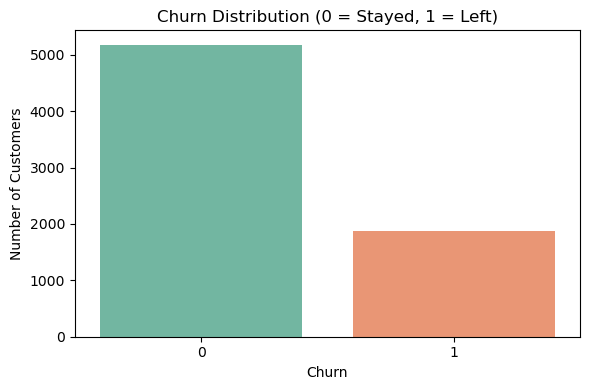

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution (0 = Stayed, 1 = Left)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

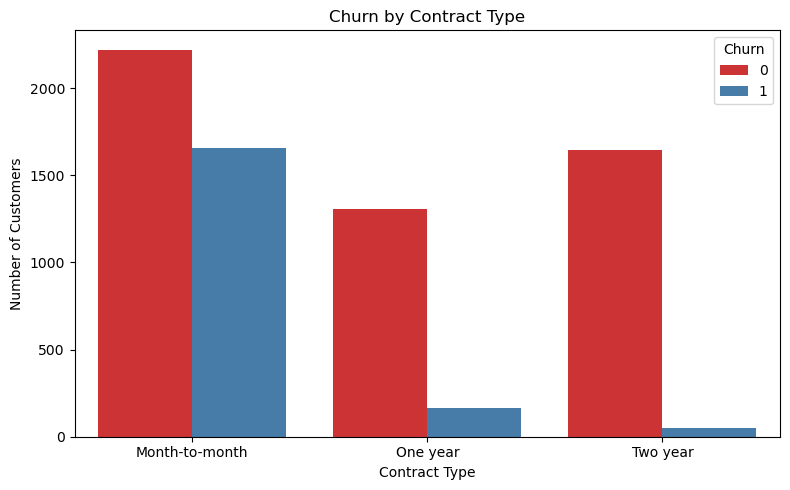

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

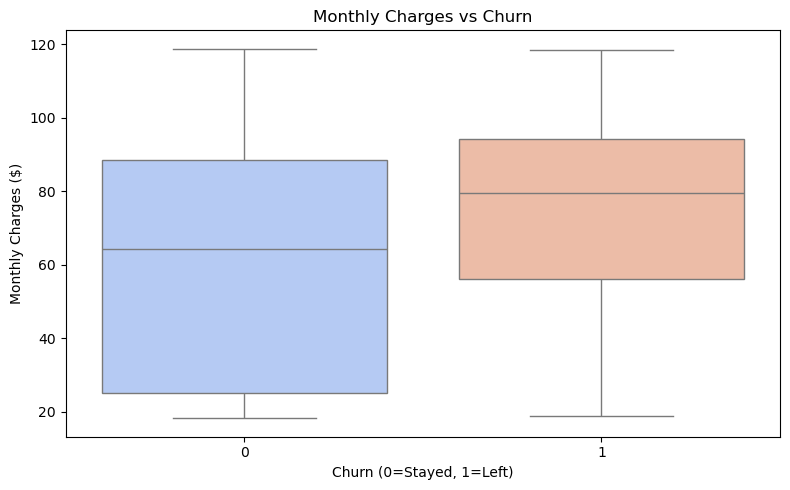

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='coolwarm', legend=False)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

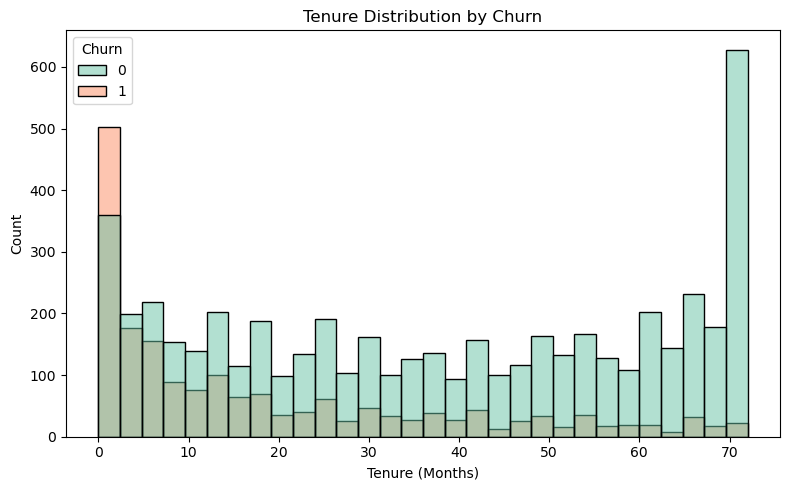

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

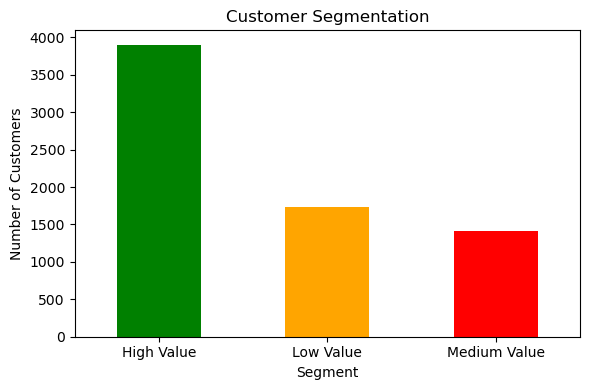

In [28]:
plt.figure(figsize=(6,4))
df['Customer_Segment'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Customer Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

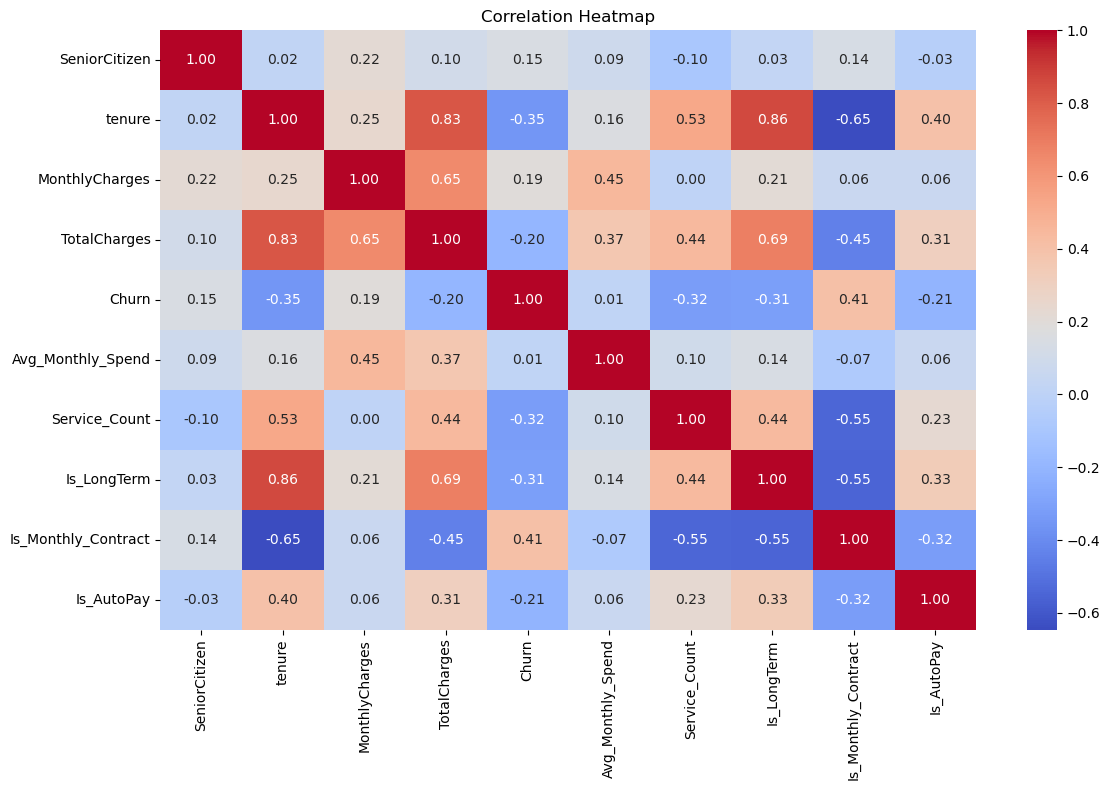

In [29]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.preprocessing import LabelEncoder


df_ml = df.copy()


df_ml.drop(['customerID', 'Customer_Segment'], axis=1, inplace=True)


le = LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

print(" Data prepared for ML!")
print("Shape:", df_ml.shape)

 Data prepared for ML!
Shape: (7043, 25)


In [31]:
from sklearn.model_selection import train_test_split
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(" Data split done!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

 Data split done!
Training size: (5634, 24)
Testing size: (1409, 24)


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)


lr_pred = lr_model.predict(X_test_scaled)


print(" Logistic Regression Results:")
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall   :", round(recall_score(y_test, lr_pred), 4))
print("F1 Score :", round(f1_score(y_test, lr_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, lr_pred), 4))

 Logistic Regression Results:
Accuracy : 0.8162
Precision: 0.6875
Recall   : 0.5603
F1 Score : 0.6174
ROC-AUC  : 0.7343


In [51]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


print(" Random Forest Results:")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_pred), 4))

 Random Forest Results:
Accuracy : 0.802
Precision: 0.6728
Recall   : 0.4906
F1 Score : 0.5674
ROC-AUC  : 0.7024


In [52]:

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(y_test, lr_pred)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_pred)
    ]
})

print(results.round(4))

      Metric  Logistic Regression  Random Forest
0   Accuracy               0.8162         0.8020
1  Precision               0.6875         0.6728
2     Recall               0.5603         0.4906
3   F1 Score               0.6174         0.5674
4    ROC-AUC               0.7343         0.7024


In [53]:
churn_proba = rf_model.predict_proba(X_test)[:, 1]


prediction_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Churn_Probability': churn_proba.round(4)
})


def assign_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

prediction_df['Risk_Category'] = prediction_df['Churn_Probability'].apply(assign_risk)

print("Churn predictions done!")
print(prediction_df.head(10))

Churn predictions done!
   Actual_Churn  Churn_Probability Risk_Category
0             1               0.76     High Risk
1             0               0.05      Low Risk
2             0               0.02      Low Risk
3             1               0.81     High Risk
4             0               0.06      Low Risk
5             1               0.22      Low Risk
6             0               0.14      Low Risk
7             0               0.01      Low Risk
8             1               0.15      Low Risk
9             1               0.30      Low Risk


Risk Category Distribution:
Risk_Category
Low Risk       1015
Medium Risk     269
High Risk       125
Name: count, dtype: int64


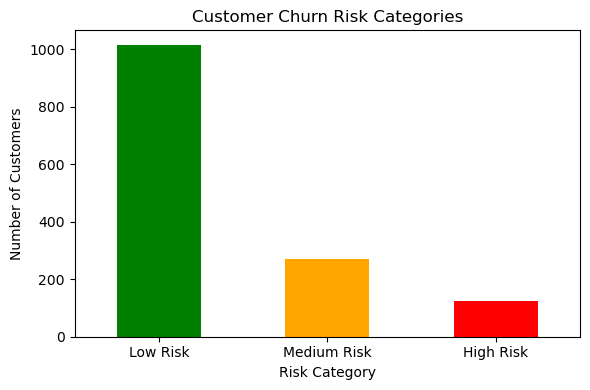

In [49]:
print("Risk Category Distribution:")
print(prediction_df['Risk_Category'].value_counts())


plt.figure(figsize=(6,4))
prediction_df['Risk_Category'].value_counts().plot(
    kind='bar', 
    color=['green', 'orange', 'red']
)
plt.title('Customer Churn Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:


sample_customer = X_test.iloc[0:1]
sample_prob = rf_model.predict_proba(sample_customer)[0][1]
sample_risk = assign_risk(sample_prob)

print(" Sample Customer Prediction:")
print(f"Churn Probability : {round(sample_prob * 100, 2)}%")
print(f"Risk Category     : {sample_risk}")

 Sample Customer Prediction:
Churn Probability : 76.0%
Risk Category     : High Risk


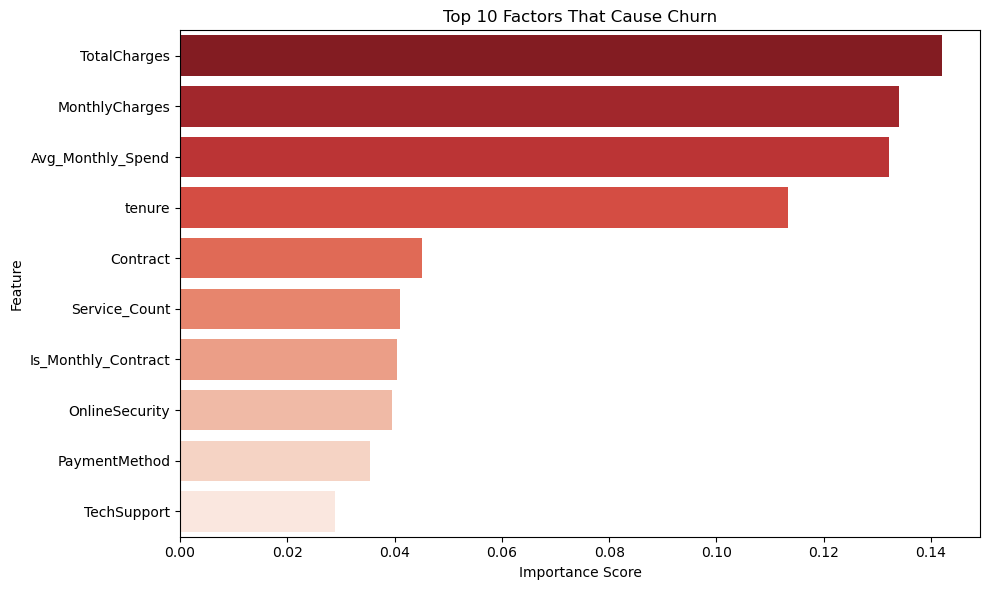


 Top 5 Churn Factors:
              Feature  Importance
18       TotalCharges    0.142024
17     MonthlyCharges    0.133955
19  Avg_Monthly_Spend    0.132141
4              tenure    0.113417
14           Contract    0.045174


In [47]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance.head(10), 
            hue='Feature', palette='Reds_r', legend=False)
plt.title('Top 10 Factors That Cause Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n Top 5 Churn Factors:")
print(feature_importance.head())

In [46]:

X_test_copy = X_test.copy()
X_test_copy['Risk_Category'] = prediction_df['Risk_Category'].values
X_test_copy['Churn_Probability'] = prediction_df['Churn_Probability'].values


high_risk = X_test_copy[X_test_copy['Risk_Category'] == 'High Risk']

print(" High Risk Customer Traits (Averages):")
print(f"Average Tenure          : {high_risk['tenure'].mean():.1f} months")
print(f"Average Monthly Charges : ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"Average Service Count   : {high_risk['Service_Count'].mean():.1f}")
print(f"% On Monthly Contract   : {high_risk['Is_Monthly_Contract'].mean()*100:.1f}%")
print(f"% Using Auto Pay        : {high_risk['Is_AutoPay'].mean()*100:.1f}%")
print(f"Total High Risk Customers: {len(high_risk)}")

 High Risk Customer Traits (Averages):
Average Tenure          : 5.2 months
Average Monthly Charges : $76.81
Average Service Count   : 3.9
% On Monthly Contract   : 100.0%
% Using Auto Pay        : 11.2%
Total High Risk Customers: 125


In [45]:

high_risk_revenue = high_risk['MonthlyCharges'].sum()
medium_risk = X_test_copy[X_test_copy['Risk_Category'] == 'Medium Risk']
medium_risk_revenue = medium_risk['MonthlyCharges'].sum()

print(" Revenue Impact Estimation (Monthly):")
print(f"High Risk Revenue at Stake   : ${high_risk_revenue:,.2f}")
print(f"Medium Risk Revenue at Stake : ${medium_risk_revenue:,.2f}")
print(f"Total Revenue at Risk        : ${high_risk_revenue + medium_risk_revenue:,.2f}")

 Revenue Impact Estimation (Monthly):
High Risk Revenue at Stake   : $9,600.90
Medium Risk Revenue at Stake : $20,178.95
Total Revenue at Risk        : $29,779.85


In [44]:
print("=" * 55)
print("       CUSTOMER CHURN ANALYSIS - SUMMARY REPORT")
print("=" * 55)

total = len(df)
churned = df['Churn'].sum()
churn_rate = (churned / total) * 100

print(f"\n Total Customers Analyzed  : {total}")
print(f" Total Churned Customers   : {churned}")
print(f" Overall Churn Rate        : {churn_rate:.2f}%")

print(f"\n Model Performance (Random Forest):")
print(f"   Accuracy  : {round(accuracy_score(y_test, rf_pred)*100, 2)}%")
print(f"   F1 Score  : {round(f1_score(y_test, rf_pred), 4)}")
print(f"   ROC-AUC   : {round(roc_auc_score(y_test, rf_pred), 4)}")

print(f"\n Risk Distribution:")
print(prediction_df['Risk_Category'].value_counts().to_string())

print(f"\n Total Monthly Revenue at Risk: ${high_risk_revenue + medium_risk_revenue:,.2f}")

print(f"\n Top Churn Factor: {feature_importance.iloc[0]['Feature']}")
print(f" 2nd Churn Factor: {feature_importance.iloc[1]['Feature']}")
print(f" 3rd Churn Factor: {feature_importance.iloc[2]['Feature']}")

print("\n" + "=" * 55)
print(" Analysis Complete!")
print("=" * 55)

       CUSTOMER CHURN ANALYSIS - SUMMARY REPORT

 Total Customers Analyzed  : 7043
 Total Churned Customers   : 1869
 Overall Churn Rate        : 26.54%

 Model Performance (Random Forest):
   Accuracy  : 80.2%
   F1 Score  : 0.5674
   ROC-AUC   : 0.7024

 Risk Distribution:
Risk_Category
Low Risk       1015
Medium Risk     269
High Risk       125

 Total Monthly Revenue at Risk: $29,779.85

 Top Churn Factor: TotalCharges
 2nd Churn Factor: MonthlyCharges
 3rd Churn Factor: Avg_Monthly_Spend

 Analysis Complete!
